### Sample notebook to process the postage stamp data
Still a work in progress but postage stamps for:
- ~14 systems in 6 bands with 10-year baselines should be accessible. 
- ~140 systems in 6 bands with 1-year baselines should be accessible. 

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

filename = "test2.h5"
bands = ["u", "g", "r", "i", "z", "y"]
lsst_colors = {
    "u": "#0c71ff",
    "g": "#49be61",
    "r": "#c61c00",
    "i": "#ffc200",
    "z": "#f341a2",
    "y": "#5d0000",
}

In [3]:
# TODO: fix metadata section in file: DONE
# TODO: generate 1-year data for whole sample: DONE
# TODO: don't save every image in a separate dataset, make one n_visit x 33 x 33 array and just store it there: DONE
# TODO: store light curve error bars 
# TODO: store PSF + noise maps


# TODO: don't provide all postage stamps -- just for extended source and lens, and just let shenming add in point source flux?
# contd: the point source flux at each epoch is already provided
# TODO: some systems are not observable in some bands (we only place cuts on lensed (no microlensing) i-band mag;
# microlensing changes the flux - makes system detectable or undetectable. 
# the color differences between the magnitudes means that some bands are just not observable -- these should be non-detections

With this notebook we provide `lens_finding_postage_stamps.h5`. Here we show the data organization in the h5 file.

In [4]:
with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())
    if not lens_keys:
        raise ValueError(f"No lens groups found in {filename}")
    else:
        print(lens_keys)
        print(len(lens_keys))
# there are 14 lenses in 6 bands with 10-year long light curves, postage stamps and metadata

['lsst_lens_0', 'lsst_lens_1', 'lsst_lens_10', 'lsst_lens_100', 'lsst_lens_101', 'lsst_lens_102', 'lsst_lens_103', 'lsst_lens_104', 'lsst_lens_105', 'lsst_lens_106', 'lsst_lens_107', 'lsst_lens_108', 'lsst_lens_109', 'lsst_lens_11', 'lsst_lens_110', 'lsst_lens_111', 'lsst_lens_112', 'lsst_lens_113', 'lsst_lens_114', 'lsst_lens_115', 'lsst_lens_116', 'lsst_lens_117', 'lsst_lens_118', 'lsst_lens_119', 'lsst_lens_12', 'lsst_lens_120', 'lsst_lens_121', 'lsst_lens_122', 'lsst_lens_123', 'lsst_lens_124', 'lsst_lens_125', 'lsst_lens_126', 'lsst_lens_127', 'lsst_lens_128', 'lsst_lens_129', 'lsst_lens_13', 'lsst_lens_130', 'lsst_lens_131', 'lsst_lens_132', 'lsst_lens_133', 'lsst_lens_134', 'lsst_lens_14', 'lsst_lens_15', 'lsst_lens_16', 'lsst_lens_17', 'lsst_lens_18', 'lsst_lens_19', 'lsst_lens_2', 'lsst_lens_20', 'lsst_lens_21', 'lsst_lens_22', 'lsst_lens_23', 'lsst_lens_24', 'lsst_lens_25', 'lsst_lens_26', 'lsst_lens_27', 'lsst_lens_28', 'lsst_lens_29', 'lsst_lens_3', 'lsst_lens_30', 'lsst_le

### pick a specific lens and look at the metadata, light curves and postage stamps

In [5]:
lens_ind = 0
with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())
    lens_key = lens_keys[lens_ind] # pick a specific key
    lens_group = hf[lens_key] # all the data for this lens lives under this group
    print(lens_group.keys())
    # lc_group = lens_group["light_curves"]

<KeysViewHDF5 ['light_curves', 'metadata', 'observation_dates', 'postage_stamps', 'static_image']>


As seen in the cell above, each `group` contains light_curves, metadata, observation dates and postage stamps.

#### metadata

In [12]:
lens_ind = 0
with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())
    lens_key = lens_keys[lens_ind] # pick a specific key
    lens_group = hf[lens_key] # all the data for this lens lives under this group
    metadata = dict(lens_group["metadata"].attrs)
    # lc_group = lens_group["light_curves"]

In [13]:
for i in metadata:
    if 'ra' in i:
        print(i)

deflector_mass_ra_0
eddington_ratio
point_source_light_g_ra_image_0
point_source_light_g_ra_image_1
point_source_light_g_ra_image_2
point_source_light_g_ra_image_3
point_source_light_i_ra_image_0
point_source_light_i_ra_image_1
point_source_light_i_ra_image_2
point_source_light_i_ra_image_3
point_source_light_r_ra_image_0
point_source_light_r_ra_image_1
point_source_light_r_ra_image_2
point_source_light_r_ra_image_3
point_source_light_u_ra_image_0
point_source_light_u_ra_image_1
point_source_light_u_ra_image_2
point_source_light_u_ra_image_3
point_source_light_y_ra_image_0
point_source_light_y_ra_image_1
point_source_light_y_ra_image_2
point_source_light_y_ra_image_3
point_source_light_z_ra_image_0
point_source_light_z_ra_image_1
point_source_light_z_ra_image_2
point_source_light_z_ra_image_3


#### light curves

In [14]:
lens_ind = 0
with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())
    lens_key = lens_keys[lens_ind] # pick a specific key
    lens_group = hf[lens_key] # all the data for this lens lives under this group
    lc_group = lens_group.get("light_curves", None)
    image0 = lc_group['image_0'] # accessing an image; there will be image 0 - 1 (double), 0 - 2 (triple), 0 - 3 (quad)
    image1 = lc_group['image_1']
    g_band_lc0 = image0['g'][:] # accessing a specific band; # other keys are u, r, i, z, y
    

In [15]:
g_band_lc0

array([21.79392829, 21.80264144, 21.83580037, 21.84184023, 21.83381663,
       21.72020853, 21.72694177, 21.72698217])

#### observation times

In [16]:
lens_ind = 0
with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())
    lens_key = lens_keys[lens_ind] # pick a specific key
    lens_group = hf[lens_key] # all the data for this lens lives under this group
    obs_group = lens_group.get("observation_dates", None)
    g_band_obs_times = obs_group.get('g')[:] # observation times for a specific band; # other keys are u, r, i, z, y
g_band_obs_times # these are the observation times as provided by the current baseline observing plan on rubin_sim

array([2.51733601e-02, 1.06232379e+00, 8.04765845e+00, 1.01126565e+01,
       1.60406916e+01, 3.22133065e+02, 3.32099030e+02, 3.32121161e+02])

#### look at the light curve

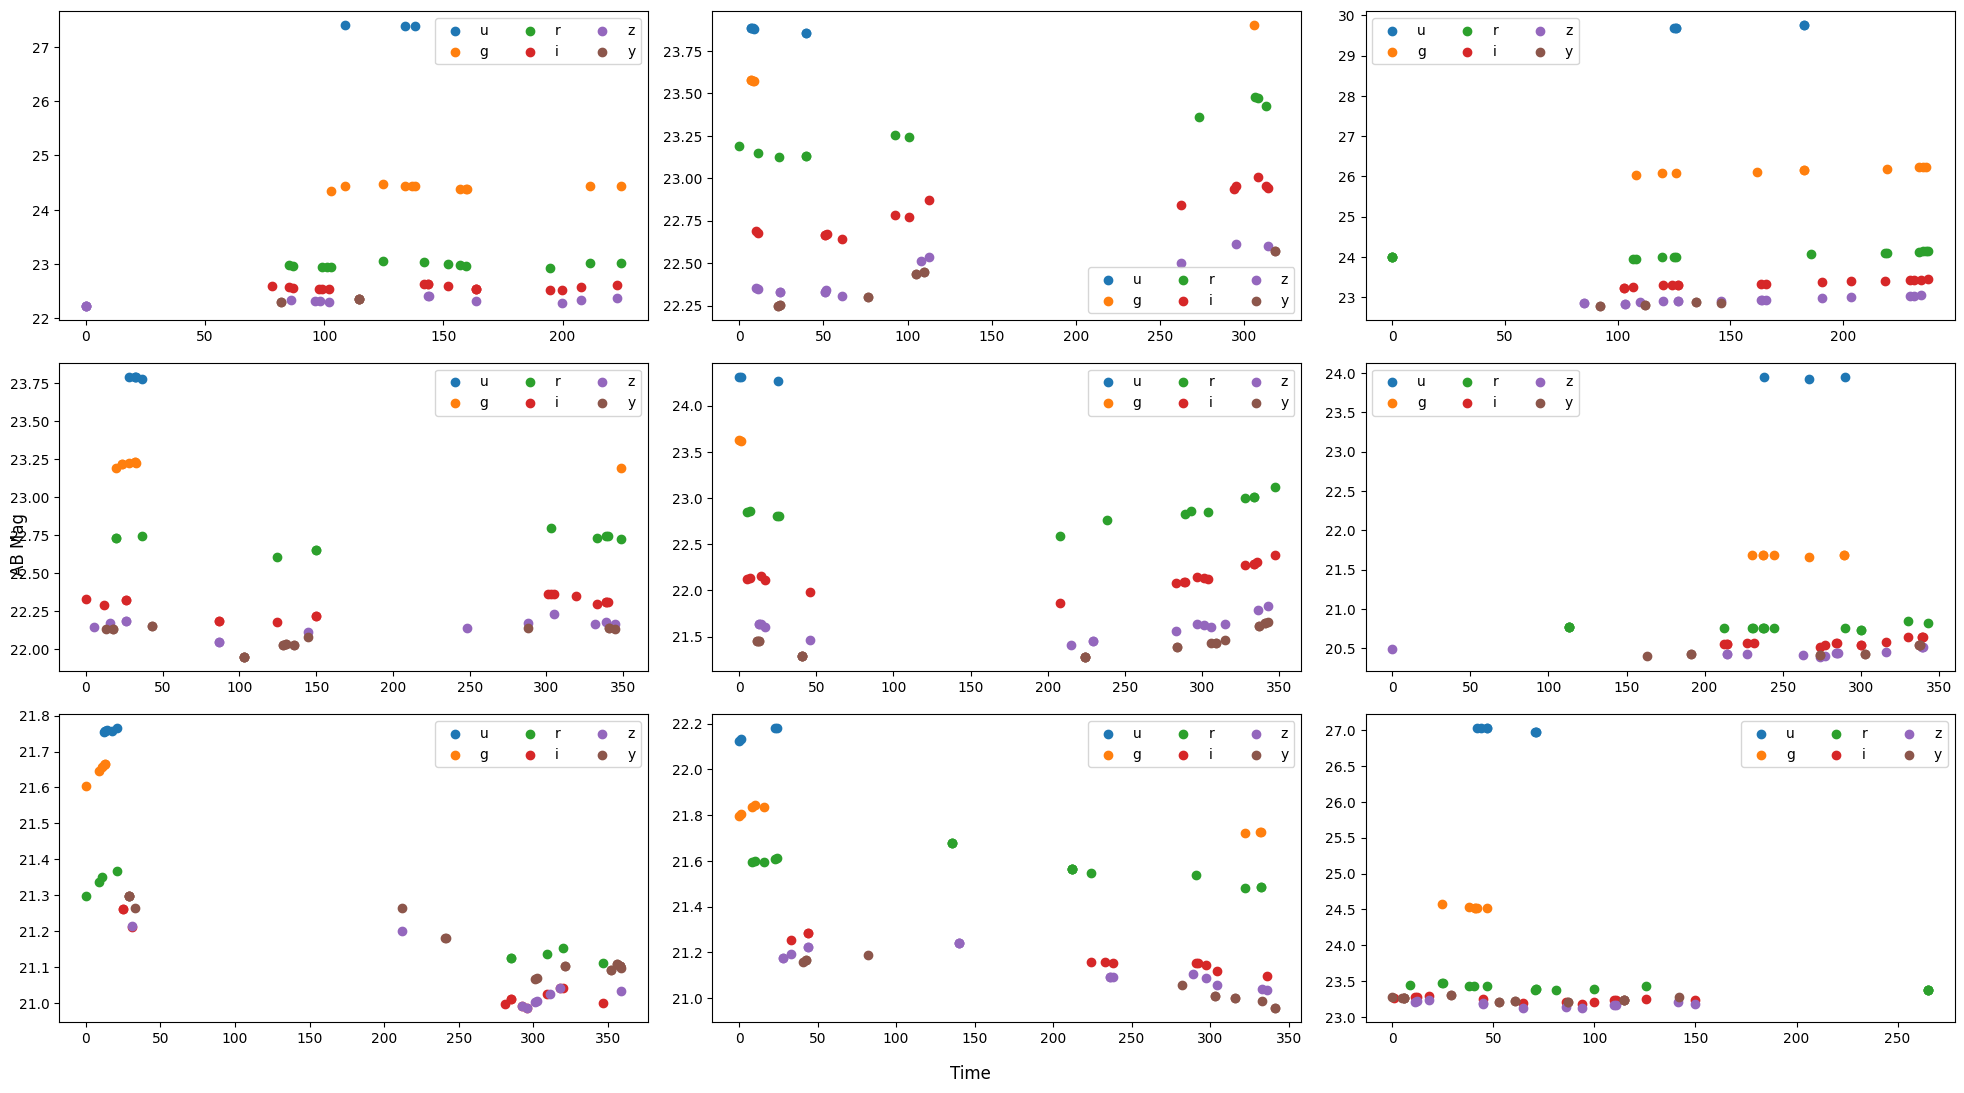

In [19]:
fig, ax = plt.subplots(3, 3, figsize=(20, 11))
lens_inds=np.random.choice(np.arange(20), 9, replace=False)
ax = ax.flatten()
i=-1
with h5py.File(filename, 'r') as hf:
    for lens_ind in lens_inds:
        i+=1
        for b in list('ugrizy'):
            lens_keys = sorted(hf.keys())
            lens_key = lens_keys[lens_ind] # pick a specific key
            lens_group = hf[lens_key] # all the data for this lens lives under this group
            obs_group = lens_group.get("observation_dates", None)
            # g_band_obs_times = obs_group.get('g')[:]
            lc_group = lens_group.get("light_curves", None)
            image0 = lc_group['image_0'] # accessing an image; there will be image 0 - 1 (double), 0 - 2 (triple), 0 - 3 (quad)
            image1 = lc_group['image_1']
            # g_band_lc0 = image0['g'][:]
            ax[i].scatter(obs_group[b][:], image0[b][:], label=b)
            ax[i].legend(ncols=3, loc='best')
    fig.supxlabel("Time")
    fig.supylabel("AB Mag")
    fig.tight_layout()

#### postage stamps

In [9]:
lens_ind = 0
with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())
    lens_key = lens_keys[lens_ind] # pick a specific key
    lens_group = hf[lens_key] # all the data for this lens lives under this group
    images_group = lens_group["postage_stamps"]
    g_band_postage_stamps = images_group.get('g') # other keys are u, r, i, z, y
    print(len(g_band_postage_stamps.keys()), g_band_postage_stamps.keys()) 
    g_band = g_band_postage_stamps['all_observations'][:] # this is just the g-band postage stamp at time 0
    # currently every observation is stored a separate dataset
    # there could be benefits to this if we additionally wanted to store PSFs under every group?
    # I think even then it would be better to store the postage stamps for a single band as a 3d array: n_visits x 33 x 33
    # and then create a separate group for associated data products such as PSFs, noise maps etc

1 <KeysViewHDF5 ['all_observations']>


### Make a gif of the observations

In [10]:
def asinh_stretch(img, vmin, vmax, scale=10.0):
    img = np.clip(img, vmin, vmax)
    scaled = (img - vmin) / (vmax - vmin)
    return np.arcsinh(scale * scaled) / np.arcsinh(scale)

In [11]:
from PIL import Image
import io
from collections import defaultdict

lens_ind = 0  # Choose which lens to visualize

# Load all postage stamps and observation times for all bands
with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())
    lens_key = lens_keys[lens_ind]
    lens_group = hf[lens_key]
    
    # Dictionary to store all observations with their times
    observations = []  # List of (time, band, image_array)
    
    for band in bands:
        # Get observation times for this band
        obs_times = lens_group["observation_dates"][band][:]
        
        # Get postage stamps for this band
        postage_stamps = lens_group["postage_stamps"][band]
        
        # Assuming postage stamps are stored as 'all_observations' with shape (n_visits, 33, 33)
        if 'all_observations' in postage_stamps:
            images = postage_stamps['all_observations'][:]
            for i, time in enumerate(obs_times):
                if i < len(images):
                    observations.append((time, band, images[i]))
        else:
            # If stored as separate time_N datasets
            time_keys = sorted([k for k in postage_stamps.keys() if k.startswith('time_')])
            for i, tk in enumerate(time_keys):
                if i < len(obs_times):
                    img = postage_stamps[tk][:]
                    observations.append((obs_times[i], band, img))

# Sort all observations by time
observations.sort(key=lambda x: x[0])

# Get global min/max for consistent normalization
all_imgs = [obs[2] for obs in observations]
global_min = min(img.min() for img in all_imgs)
global_max = max(img.max() for img in all_imgs)

print(f"Total observations across all bands: {len(observations)}")
print(f"Time range: {observations[0][0]:.2f} to {observations[-1][0]:.2f} MJD")

Total observations across all bands: 67
Time range: 0.00 to 165.60 MJD


In [12]:
# Create frames for the GIF
frames = []

# Track the most recent image for each band
current_images = {band: None for band in bands}
current_times = {band: None for band in bands}

# Create a frame for each observation event
for idx, (time, band, image) in enumerate(observations):
    # Update the current image for this band
    current_images[band] = image
    current_times[band] = time
    
    # Create figure with 6 subplots (2 rows x 3 cols)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for i, b in enumerate(bands):
        ax = axes[i]
        
        if current_images[b] is not None:
            # Apply asinh stretch for better visualization
            # img_stretched = asinh_stretch(current_images[b], global_min, global_max)
            ax.imshow(current_images[b], norm='asinh', vmin=global_min, vmax=global_max, origin="lower", cmap="viridis")
            title = f"{b}-band\nMJD: {current_times[b]:.2f}"
        else:
            # No observation yet for this band
            ax.imshow(np.zeros((33, 33)), origin="lower", cmap="viridis")
            title = f"{b}-band\nNo observation"
        
        ax.set_title(title, color=lsst_colors[b])
        ax.axis('off')
    
    fig.suptitle(f"Observation {idx+1}/{len(observations)} - MJD: {time:.2f}", fontsize=16)
    plt.tight_layout()
    
    # Save frame to buffer
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=80, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    plt.close(fig)
    buf.close()
    
    if (idx + 1) % 20 == 0:
        print(f"Processed {idx+1}/{len(observations)} frames")

print(f"Created {len(frames)} frames")

Processed 20/67 frames
Processed 40/67 frames
Processed 60/67 frames
Created 67 frames


In [13]:
# Save as GIF
output_filename = f"lens_{lens_ind}_observations.gif"
frames[0].save(
    output_filename,
    save_all=True,
    append_images=frames[1:],
    duration=200,  # milliseconds per frame
    loop=0  # loop forever
)

print(f"GIF saved as: {output_filename}")
print(f"Total frames: {len(frames)}")

GIF saved as: lens_0_observations.gif
Total frames: 67


#### Make an rgb image with all 6 bands

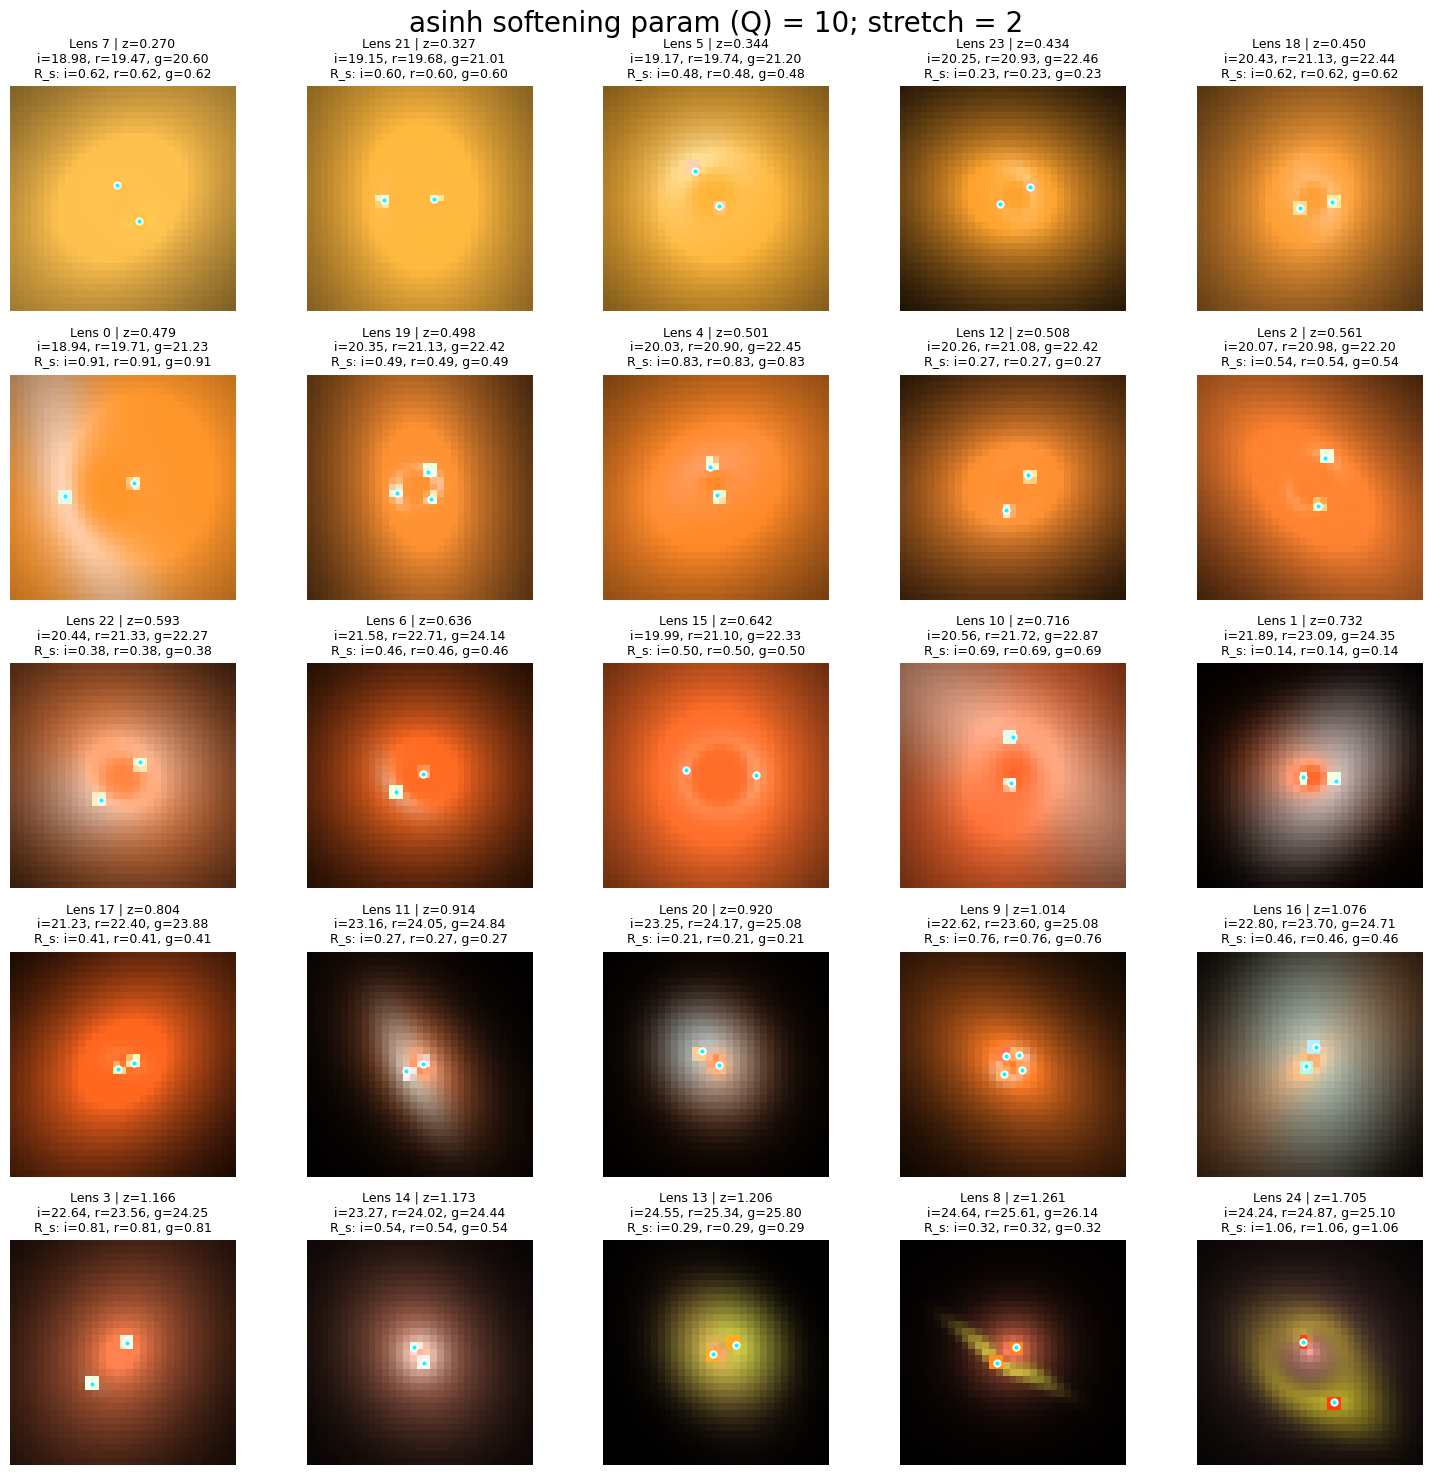

In [36]:
from astropy.visualization import make_lupton_rgb
from astropy.stats import sigma_clip
from lenstronomy.Util.util import map_coord2pix
fig, ax = plt.subplots(5, 5, figsize=(15, 15))
# lens_inds = np.random.choice(np.arange(140), 25)  # Choose which lens to visualize
lens_inds = np.arange(0, 25)
axi = 0
ax = ax.flatten()

# Rendering params
Q = 10
stretch = 2

# LSST pixel scale: 0.2 arcsec/pixel
pixel_scale_arcsec = 0.2
# Transform matrix converts arcseconds to pixel offsets
# Since 0.2 arcsec/pixel, we have 1/0.2 = 5 pixels per arcsecond
transform_matrix = np.array([[1/pixel_scale_arcsec, 0], [0, 1/pixel_scale_arcsec]])

with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())

    # Build (lens_ind, redshift) table and sort by redshift
    lens_info = []
    for lens_ind in lens_inds:
        lens_key = f"lsst_lens_{lens_ind}"
        if lens_key not in hf:
            continue
        lens_group = hf[lens_key]
        metadata = dict(lens_group["metadata"].attrs)
        z_deflector = metadata.get("deflector_redshift", np.nan)
        lens_info.append((lens_ind, z_deflector))

    # Sort ascending redshift; NaNs go to the end
    lens_info_sorted = sorted(
        lens_info,
        key=lambda x: (np.isnan(x[1]), x[1] if not np.isnan(x[1]) else np.inf),
    )

    # Plot in sorted order
    for lens_ind, deflector_redshift in lens_info_sorted:
        lens_key = f"lsst_lens_{lens_ind}"
        lens_group = hf[lens_key]
        metadata = dict(lens_group["metadata"].attrs)

        coadds = {}
        for band in ["i", "r", "g"]:
            postage_stamps = lens_group["postage_stamps"][band]
            images = postage_stamps["all_observations"][:]
            clipped_data = sigma_clip(images, sigma=10, axis=0, cenfunc="mean", maxiters=5)
            coadds[band] = np.ma.median(clipped_data, axis=0)

        imag, rmag, gmag = [metadata[f"deflector_light_{band}_magnitude"] for band in list("irg")]
        imag, rmag, gmag = [metadata[f"deflector_light_{band}_magnitude"] for band in list("irg")]
        isize, rsize, gsize = [metadata[f"deflector_light_{band}_R_sersic"] for band in list("irg")]
        
        # Extract point source positions (stored in arcseconds relative to image center)
        ps_positions = []
        for i in range(int(metadata.get('num_ps_images', 0))):
            ra_key = f'point_source_light_i_ra_image_{i}'
            dec_key = f'point_source_light_i_dec_image_{i}'
            if ra_key in metadata and dec_key in metadata:
                ps_positions_i = [metadata[ra_key], metadata[dec_key]]
                ps_positions.append(ps_positions_i)

        rgb_image = make_lupton_rgb(coadds["i"], coadds["r"], coadds["g"], Q=Q, stretch=stretch)
        ax[axi].imshow(rgb_image)
        
        # Transform arcsecond positions to pixel coordinates
        if ps_positions:
            ps_positions = np.array(ps_positions).T
            ps_pos_on_image = map_coord2pix(
                ps_positions[0], ps_positions[1], 
                32/2, 32/2,  # Image center in pixels
                transform_matrix
            )
            # Plot point sources as small circles with contrasting color
            ax[axi].scatter(ps_pos_on_image[0], ps_pos_on_image[1], 
                          s=20, c='cyan', marker='o', edgecolors='white', linewidths=1.5)
        
        ax[axi].set_title(
            (
                f"Lens {lens_ind} | z={deflector_redshift:.3f}\n"
                f"i={imag:.2f}, r={rmag:.2f}, g={gmag:.2f}\n"
                f"R_s: i={isize:.2f}, r={rsize:.2f}, g={gsize:.2f}"
            ),
            fontsize=9,
        )
        ax[axi].axis("off")
        axi += 1

# Hide any remaining axes if fewer than 25 valid lenses
for j in range(axi, len(ax)):
    ax[j].axis("off")

fig.suptitle(f"asinh softening param (Q) = {Q}; stretch = {stretch}", size=20)
fig.tight_layout()

Created coadds for lens lsst_lens_0
Coadd shape for each band: (33, 33)


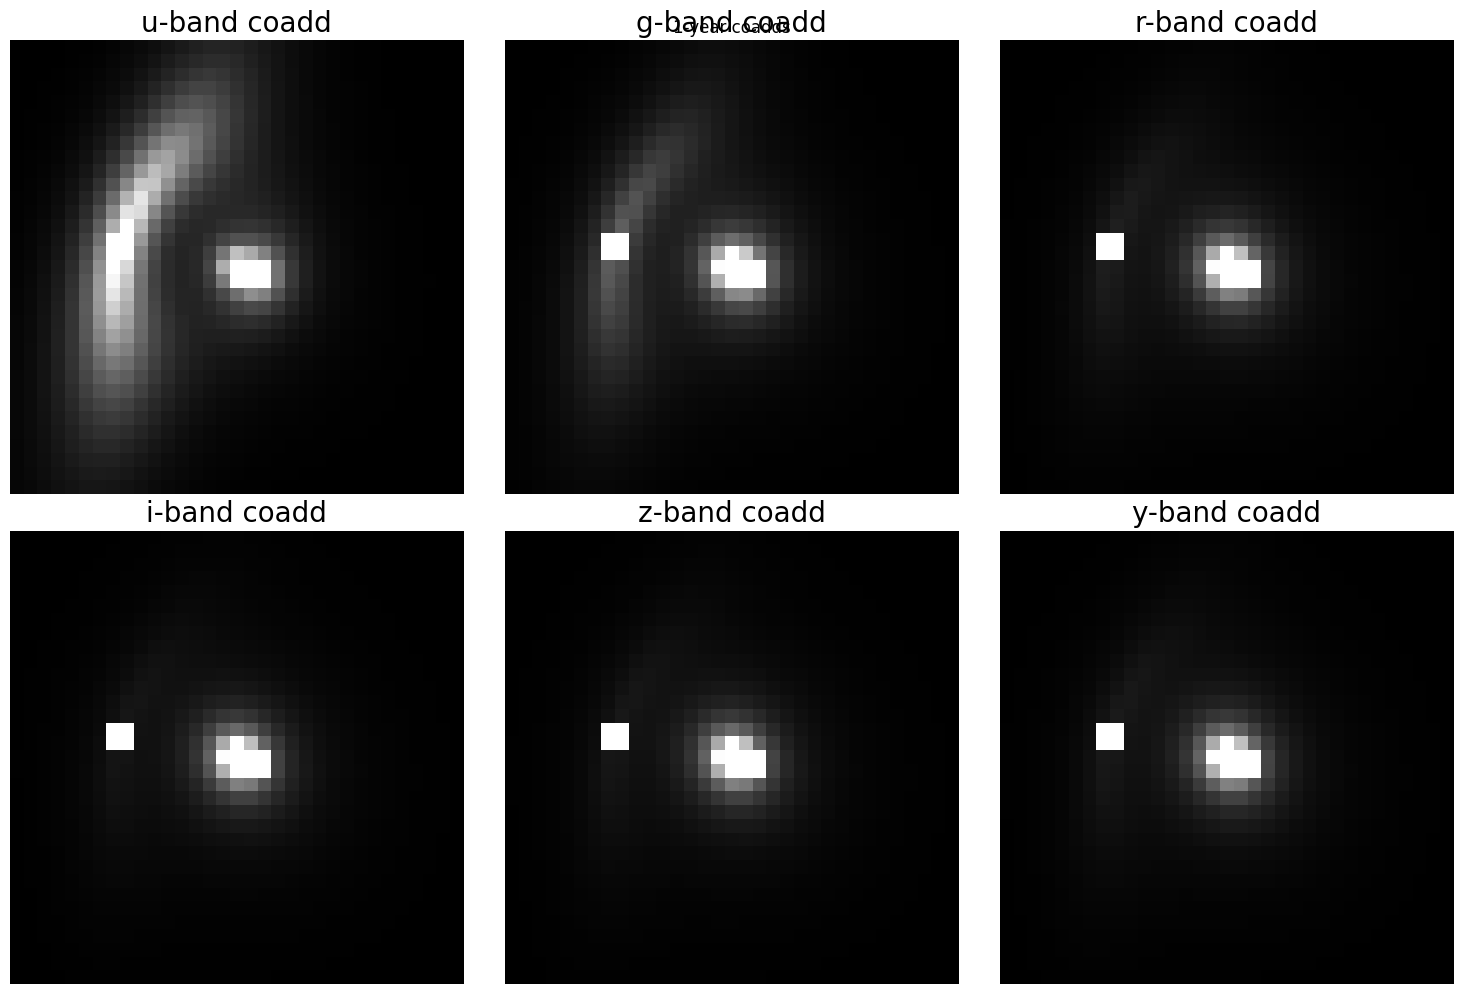

In [14]:

lens_ind = 0  # Choose which lens to visualize

# Load all postage stamps for all bands and create coadds
with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())
    lens_key = lens_keys[lens_ind]
    lens_group = hf[lens_key]
    
    # Create coadds for each band by averaging all observations
    coadds = {}
    for band in bands:
        postage_stamps = lens_group["postage_stamps"][band]
        
        if 'all_observations' in postage_stamps:
            images = postage_stamps['all_observations'][:]
            coadds[band] = np.median(images, axis=0)
        else:
            # If stored as separate time_N datasets
            time_keys = sorted([k for k in postage_stamps.keys() if k.startswith('time_')])
            imgs = [postage_stamps[tk][:] for tk in time_keys]
            coadds[band] = np.median(np.array(imgs), axis=0)
    
    print(f"Created coadds for lens {lens_key}")
    print(f"Coadd shape for each band: {coadds['g'].shape}")
    
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, band in enumerate(bands):
    ax = axes[i]
    img = coadds[band]
    vmin, vmax = np.percentile(img, [1, 99])
    ax.imshow(img, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(f'{band}-band coadd',   fontsize=20)
    ax.axis('off')

plt.tight_layout()
fig.suptitle("1-year coadds")
plt.savefig(f'lens_{lens_ind}_coadds_individual.png', dpi=150, bbox_inches='tight')


#### lupton RGB with two groups

aadya: make (i, r, g) and then (y, z, u), then merge them.

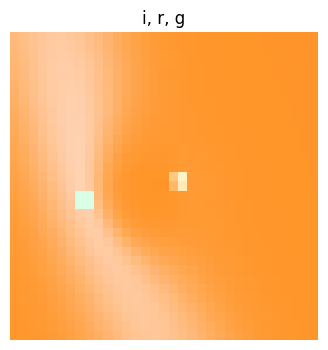

In [16]:
# u g r i z y
# check deflector magnitude and size, sersic index
global_max = np.array([np.max(i) for i in coadds.values()])
global_min = np.array([np.min(i) for i in coadds.values()])

rgb_image = make_lupton_rgb(coadds['i'], coadds['r'], coadds['g'], 
                            stretch=0.5, 
                            )
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(rgb_image) # apply arcsin
ax.set_title("i, r, g")
ax.axis('off');


In [133]:
np.array([np.max(i) for i in coadds.values()])
np.array([np.min(i) for i in coadds.values()])

array([0.03942264, 1.06897598, 3.7020945 , 6.27148104, 6.20979603,
       3.23951088])

In [123]:
global_max

dict_values([array([[0.6115631 , 0.87079277, 1.19155145, ..., 0.05534003, 0.05055739,
        0.04612896],
       [0.64159316, 0.93192521, 1.30541146, ..., 0.06105248, 0.05542147,
        0.05026598],
       [0.66697146, 0.98751381, 1.41549027, ..., 0.0672785 , 0.06065974,
        0.05467184],
       ...,
       [0.07351285, 0.09423739, 0.12560894, ..., 0.06330414, 0.05305877,
        0.04541167],
       [0.06465243, 0.08115539, 0.10574728, ..., 0.05931829, 0.04951146,
        0.04227843],
       [0.05705517, 0.07021522, 0.08952099, ..., 0.05577243, 0.04631493,
        0.03942264]]), array([[ 5.10791603,  7.01774243,  9.36990218, ...,  1.67792236,
         1.53433979,  1.40079305],
       [ 5.39173983,  7.53290637, 10.27116791, ...,  1.85035713,
         1.68149753,  1.52614831],
       [ 5.64856867,  8.01641254, 11.15532865, ...,  2.03806761,
         1.83984054,  1.65956967],
       ...,
       [ 1.72321892,  1.99831978,  2.36117061, ...,  1.60456412,
         1.41999051,  1.2647798 

In [83]:
rgb1 = make_lupton_rgb(coadds['r'], coadds['g'], coadds['u'], 
                    stretch=0.5)
# u g r i z y
rgb2 = make_lupton_rgb(coadds['y'], coadds['z'], coadds['i'], 
                       stretch=0.5)

rgb_standard = make_lupton_rgb(coadds['i'], coadds['r'], coadds['g'], 
                               stretch=0.5)
rgb1

# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# axes[0].imshow(rgb1, norm='asinh', origin='lower')
# axes[0].set_title('r, g, u', fontsize=14)
# axes[0].axis('off')

# axes[1].imshow(rgb2, norm='asinh', origin='lower')
# axes[1].set_title('y, z, i', fontsize=14)
# axes[1].axis('off')

# axes[2].imshow(rgb_standard, norm='asinh',origin='lower')
# axes[2].set_title('i, r, g', fontsize=14)
# axes[2].axis('off')

# plt.tight_layout()
# plt.savefig(f'lens_{lens_ind}_lupton_rgb.png', dpi=150, bbox_inches='tight')
# plt.show()

array([[[254, 167,  20],
        [255, 179,  22],
        [255, 189,  24],
        ...,
        [255,  71,   2],
        [255,  71,   2],
        [255,  71,   2]],

       [[255, 165,  19],
        [255, 178,  22],
        [255, 189,  24],
        ...,
        [254,  71,   2],
        [255,  71,   2],
        [255,  71,   2]],

       [[255, 163,  19],
        [255, 177,  21],
        [255, 188,  23],
        ...,
        [255,  71,   2],
        [254,  71,   2],
        [255,  71,   2]],

       ...,

       [[255,  76,   3],
        [255,  79,   3],
        [255,  82,   4],
        ...,
        [255,  74,   2],
        [255,  73,   2],
        [254,  73,   2]],

       [[254,  75,   3],
        [255,  78,   3],
        [255,  81,   4],
        ...,
        [255,  75,   3],
        [255,  74,   2],
        [254,  73,   2]],

       [[255,  75,   3],
        [255,  77,   3],
        [255,  79,   3],
        ...,
        [255,  76,   3],
        [254,  74,   2],
        [254,  73,   2]]

#### Flux sanity checks

In [49]:
### how much flux in image
-2.5*np.log10(np.mean(g_band[0])) + 28.51, g_band_lc0 # 28.51 is the g-band ZP

(22.089795454861893,
 array([18.32732452, 18.3273235 , 18.34898442, 18.34963944, 18.3496103 ,
        18.3284824 , 18.33235213, 18.33990834, 18.34213397, 18.30833958,
        18.30953132, 18.29116145, 18.26861692, 18.26861623, 18.28970137]))

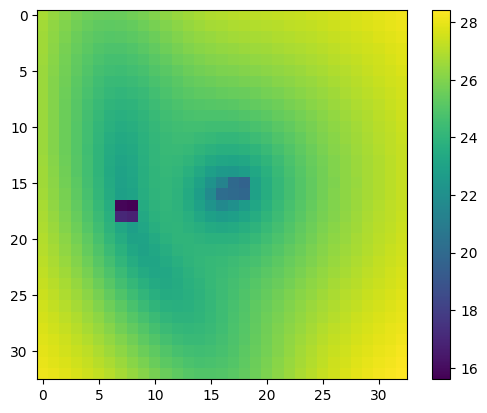

In [50]:
plt.imshow(-2.5*np.log10(g_band[0]) + 28.51, norm='linear')
plt.colorbar(); ### looking at the image, it looks like the flux in the light curve and image is consistent

#### metadata

In [ ]:
lens_ind = 0
with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())
    lens_key = lens_keys[lens_ind] # pick a specific key
    lens_group = hf[lens_key] # all the data for this lens lives under this group
    metadata = lens_group['metadata']
    all_attributes = {}
    for k,v in metadata.attrs.items():
        all_attributes[k]=v

{'ID': 'GAL-QSO-LENS_-0.0007_0.0032', 'M_g': np.float64(-20.881109523047023), 'M_i': np.float64(-21.697469232408054), 'M_r': np.float64(-21.535496726652877), 'M_u': np.float64(-18.797209330423147), 'M_y': np.float64(-21.876106176841592), 'M_z': np.float64(-21.87104786286669), 'black_hole_mass_exponent': np.float64(7.688892437367014), 'black_hole_spin': np.float64(0.8960455722323811), 'deflector_light_g_R_sersic': np.float64(0.27406032979234074), 'deflector_light_g_center_x': np.float64(-0.0007296763699117813), 'deflector_light_g_center_y': np.float64(0.003157156624114635), 'deflector_light_g_e1': np.float64(-0.06642173603521123), 'deflector_light_g_e2': np.float64(0.0073705714335975826), 'deflector_light_g_magnitude': np.float64(25.34468145609846), 'deflector_light_g_n_sersic': np.float64(4.0), 'deflector_light_i_R_sersic': np.float64(0.27406032979234074), 'deflector_light_i_center_x': np.float64(-0.0007296763699117813), 'deflector_light_i_center_y': np.float64(0.003157156624114635), '

In [65]:
all_attributes

{'ID': 'GAL-QSO-LENS_-0.0007_0.0032',
 'M_g': np.float64(-20.881109523047023),
 'M_i': np.float64(-21.697469232408054),
 'M_r': np.float64(-21.535496726652877),
 'M_u': np.float64(-18.797209330423147),
 'M_y': np.float64(-21.876106176841592),
 'M_z': np.float64(-21.87104786286669),
 'black_hole_mass_exponent': np.float64(7.688892437367014),
 'black_hole_spin': np.float64(0.8960455722323811),
 'deflector_light_g_R_sersic': np.float64(0.27406032979234074),
 'deflector_light_g_center_x': np.float64(-0.0007296763699117813),
 'deflector_light_g_center_y': np.float64(0.003157156624114635),
 'deflector_light_g_e1': np.float64(-0.06642173603521123),
 'deflector_light_g_e2': np.float64(0.0073705714335975826),
 'deflector_light_g_magnitude': np.float64(25.34468145609846),
 'deflector_light_g_n_sersic': np.float64(4.0),
 'deflector_light_i_R_sersic': np.float64(0.27406032979234074),
 'deflector_light_i_center_x': np.float64(-0.0007296763699117813),
 'deflector_light_i_center_y': np.float64(0.0031

This section is under construction, the metadata information was not save properly

### visualizing images and light curves

['lsst_lens_0', 'lsst_lens_1', 'lsst_lens_10', 'lsst_lens_100', 'lsst_lens_101', 'lsst_lens_102', 'lsst_lens_103', 'lsst_lens_104', 'lsst_lens_105', 'lsst_lens_106', 'lsst_lens_107', 'lsst_lens_108', 'lsst_lens_109', 'lsst_lens_11', 'lsst_lens_110', 'lsst_lens_111', 'lsst_lens_112', 'lsst_lens_113', 'lsst_lens_114', 'lsst_lens_115', 'lsst_lens_116', 'lsst_lens_117', 'lsst_lens_118', 'lsst_lens_119', 'lsst_lens_12', 'lsst_lens_120', 'lsst_lens_121', 'lsst_lens_122', 'lsst_lens_123', 'lsst_lens_124', 'lsst_lens_125', 'lsst_lens_126', 'lsst_lens_127', 'lsst_lens_128', 'lsst_lens_129', 'lsst_lens_13', 'lsst_lens_130', 'lsst_lens_131', 'lsst_lens_132', 'lsst_lens_133', 'lsst_lens_134', 'lsst_lens_135', 'lsst_lens_136', 'lsst_lens_137', 'lsst_lens_138', 'lsst_lens_139', 'lsst_lens_14', 'lsst_lens_140', 'lsst_lens_141', 'lsst_lens_142', 'lsst_lens_143', 'lsst_lens_144', 'lsst_lens_145', 'lsst_lens_146', 'lsst_lens_147', 'lsst_lens_148', 'lsst_lens_149', 'lsst_lens_15', 'lsst_lens_150', 'lsst_

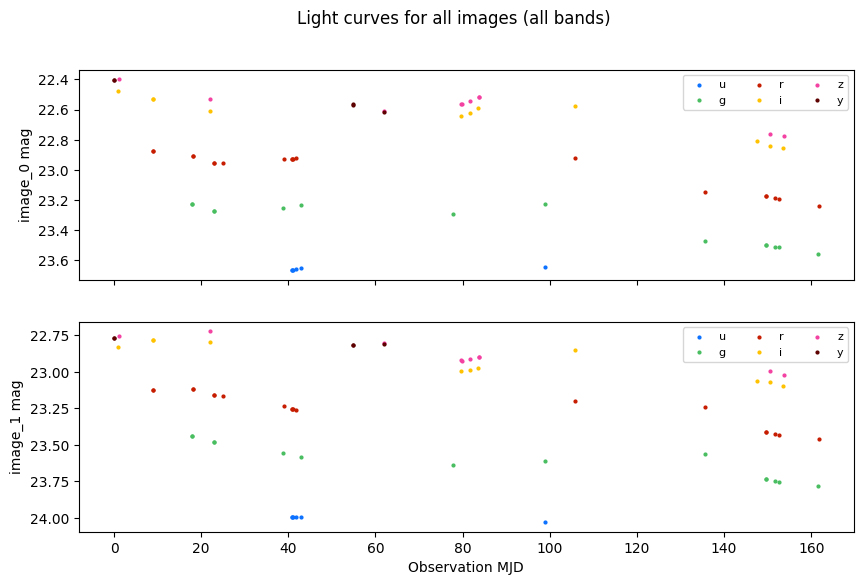

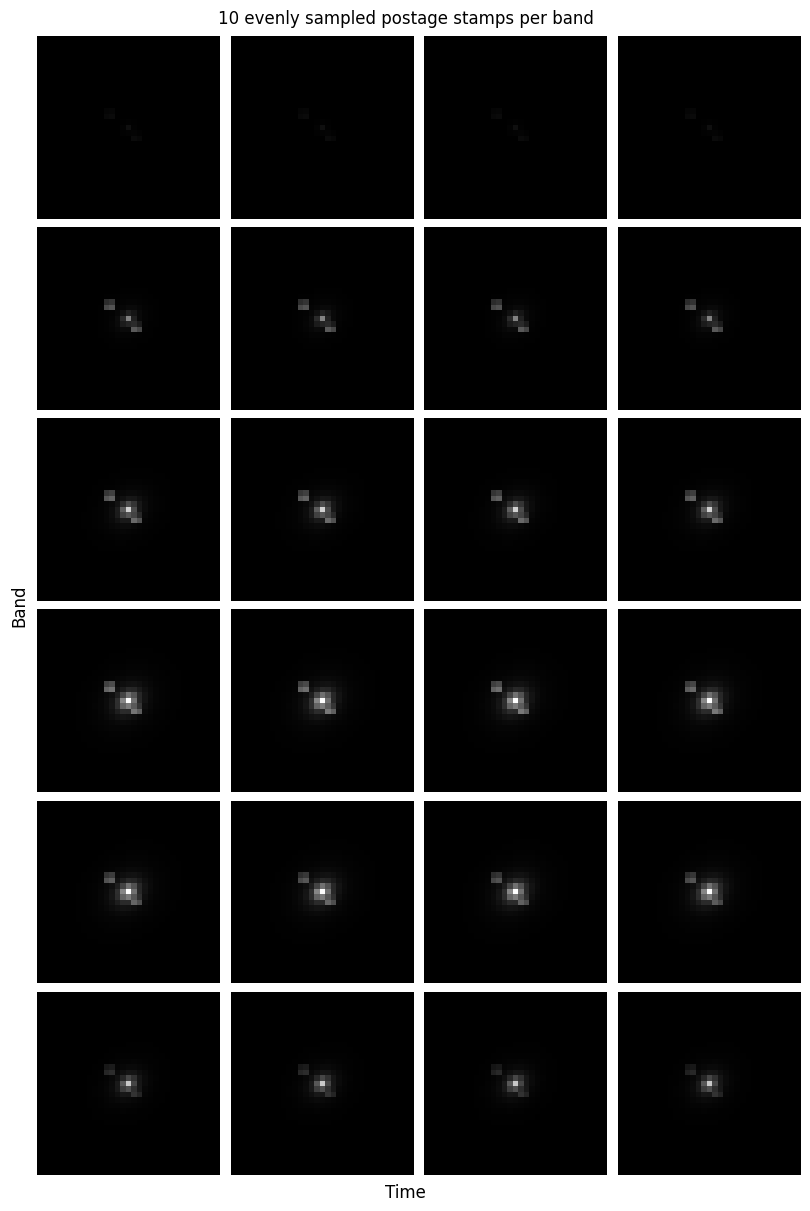

In [ ]:
#### THIS IS AI-GENERATED CODE
with h5py.File(filename, "r") as hf:
    lens_keys = sorted(hf.keys())
    print(lens_keys)
    if not lens_keys:
        raise ValueError(f"No lens groups found in {filename}")
    lens_key = lens_keys[100]
    lens_group = hf[lens_key]
    lc_group = lens_group["light_curves"]
    obs_group = lens_group.get("observation_dates", None)
    image_keys = sorted(lc_group.keys(), key=lambda k: int(k.split("_")[1]))
    print(f"Using lens group: {lens_key}")

    ### plotting the lc
    n_images = len(image_keys)
    fig, axes = plt.subplots(
        n_images, 1, figsize=(10, 3 * n_images), sharex=True
    )
    for idx, image_key in enumerate(image_keys):
        ax = axes[idx]
        for band in bands:
            mags = lc_group[image_key][band][()]
            times = obs_group[band][:]
            color = lsst_colors.get(band, None)
            ax.scatter(times, mags, s=4, label=band, color=color)
        ax.invert_yaxis()
        ax.set_ylabel(f"{image_key} mag")
        ax.legend(ncol=3, fontsize=8)
    axes[-1].set_xlabel("Observation MJD" if obs_group is not None else "Time index")
    fig.suptitle("Light curves for all images (all bands)")
    plt.show()

    ### image norm
    images_group = lens_group["postage_stamps"]
    all_images = []
    all_images_dict ={}
    for band in bands:
        band_group = images_group[band]
        time_keys = sorted(
            band_group.keys(), key=lambda k: int(k.split("_")[1])
        )
        for tk in time_keys:
            all_images_dict[band] = band_group[tk][:]
            all_images.append( band_group[tk][:])
    global_min = min(img.min() for img in all_images)
    global_max = max(img.max() for img in all_images)
    num_samples=4
    fig, axes = plt.subplots(
        len(bands), num_samples, figsize=(2 * num_samples, 2 * len(bands)), constrained_layout=True
    )
    for bi, band in enumerate(bands):
        band_group = images_group[band]
        time_keys = sorted(
            band_group.keys(), key=lambda k: int(k.split("_")[1])
        )
        n_times = len(time_keys)
        for j in range(num_samples):
            ax = axes[bi, j]
            img = band_group[f'time_{j}'][:]
            img_s = asinh_stretch(img, global_min, global_max)
            ax.imshow(img_s, origin="lower", cmap="gray", vmin=0, vmax=1)
            # ax.set_title(f"t={tk.split('_')[1]}", fontsize=8)
            ax.axis("off")
        axes[bi, 0].set_ylabel(band)

    fig.supxlabel("Time")
    fig.supylabel("Band")
    fig.suptitle("10 evenly sampled postage stamps per band")
    plt.show()